In [1]:
import lfox
import lfox.lattice as lat
import lfox.evolution.hmc as lhmc
import jax
import jax.numpy as jnp
import numpy as np

# Imports below require "dev" environment
import matplotlib.pyplot as plt
import lsqfit
import gvar as gv
import tqdm

# Double precision!
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_threefry_partitionable", True)

In [12]:
def plot_gvcorr(gc, color='blue', log_scale=False, offset=0.0, x=None, xr_offset=True, 
    label=None, marker='o', markersize=8, capthick=0, open_symbol=False, fill=False, linestyle=' ', eb_linestyle=' '):
    if x is None:
        x = np.arange(0,len(gc))

    if fill:
        y = np.asarray([gv.mean(g) for g in gc])
        yerr = np.asarray([gv.sdev(g) for g in gc])
        eplot = plt.plot(x=x+offset, y=y, color=color, label=label)
        eplot = plt.fill_between(x+offset, y-yerr, y+yerr, alpha=0.5, edgecolor='k', facecolor=color)
    else:
        if open_symbol:
            eplot = plt.errorbar(x=x + offset, y=[ gv.mean(g) for g in gc], yerr= [gv.sdev(g) for g in gc], 
                marker=marker, markersize=markersize, capthick=capthick, 
                linestyle=linestyle, color=color, label=label, mfc='None', mec=color, mew=1)
        else:
            eplot = plt.errorbar(x=x + offset, y=[ gv.mean(g) for g in gc], yerr= [gv.sdev(g) for g in gc], 
                marker=marker, markersize=markersize, capthick=capthick, 
                linestyle=linestyle, color=color, label=label)
						 
        if eb_linestyle != ' ':
            eplot[-1][0].set_linestyle(eb_linestyle)

    if (log_scale):
        plt.yscale('symlog')
    
    if (xr_offset):
        plt.xlim(x[0]-0.2, x[-1]+0.2)

    return eplot

In [80]:
d=2

class ACAction(lhmc.Action):
    @staticmethod
    @jax.jit
    def _Sjax(phi, beta, lamb):
        Stot = phi**2
        for mu in range(d):
            Stot -= beta * phi * phi.nn_field(mu)

        Stot += lamb * (phi**2 - 1)**2

        return Stot

    def _compute_forces(self):
        self.grads = {
            'phi': jax.jit(jax.grad(lambda phi, beta, lamb: jnp.sum(self._Sjax(phi, beta, lamb).F))),
        }

        def force_func(fields):
            return {'phi': self.grads['phi'](fields['phi'], self.params['beta'], self.params['lamb']) }

        self.forces = force_func


In [81]:
ACAction._SJax(phi8, 0, 0.06268)

AttributeError: type object 'ACAction' has no attribute '_SJax'

In [3]:
@jax.jit
def mag(phi):
    m = jnp.sum(phi.F)
    return jnp.array([m, m**2, m**4])

def mag_obs(fields, params):
    return mag(fields['phi'])

In [87]:
Lat8 = lat.SquareLattice(dims=(8,8))
phi8 = lat.LatticeField(Lat8)
phi8.field = np.ones_like(phi8.F)

betas = np.linspace(0.5,0.7,20)
mags = {}

for b in betas:
    S8 = ACAction({'phi': phi8}, params={'beta': b, 'lamb': 1})

    HMC = lhmc.HMCEvolver(
        action=S8,
        seed=int(68015+b*138),
        integrator=lhmc.OmelyanIntegrator(eps=0.2, Nstep=5),
        observables={'mag': (mag_obs, 500)},
    )

    HMC.evolve(ntraj=500, warmup=True)

    for _ in range(200):
        HMC.evolve(ntraj=1000)

    print(f"beta = {b}: avg. accept prob = ", np.mean(HMC.monitor['P_acc']))

    mags[b] = np.array(HMC.obs_chain['mag'])


beta = 0.5: avg. accept prob =  1.0000426179503323
beta = 0.5105263157894737: avg. accept prob =  0.9999604851335182
beta = 0.5210526315789473: avg. accept prob =  1.0001531385008342
beta = 0.531578947368421: avg. accept prob =  0.9999161864481477
beta = 0.5421052631578948: avg. accept prob =  0.9999098508015823
beta = 0.5526315789473684: avg. accept prob =  1.0000500326030337
beta = 0.5631578947368421: avg. accept prob =  1.0000208093142027
beta = 0.5736842105263158: avg. accept prob =  1.0001114033044132
beta = 0.5842105263157895: avg. accept prob =  1.0000528220740226
beta = 0.5947368421052631: avg. accept prob =  0.999817658969326
beta = 0.6052631578947368: avg. accept prob =  1.0000753608611297
beta = 0.6157894736842104: avg. accept prob =  1.000029168766755
beta = 0.6263157894736842: avg. accept prob =  0.9999918481871353
beta = 0.6368421052631579: avg. accept prob =  1.000011909042736
beta = 0.6473684210526316: avg. accept prob =  1.0002047887832861
beta = 0.6578947368421052: av

In [88]:
np.mean(HMC.monitor['P_acc'])

1.0000775456060491

In [89]:
def binder(mag_array, tc=0):
    m2_ave = np.mean(mag_array[tc:,1])
    m4_ave = np.mean(mag_array[tc:,2])

    return 1.5 - m4_ave / (2 * m2_ave**2)

def binder_jk(mag_array, tc=0):
    BC_jack = []
    Nsamp = mag_array.shape[0]
    mu_BC = binder(mag_array, tc=tc)

    for i in range(Nsamp):
        mag_i = np.delete(mag_array, i, axis=0)
        BC_i = binder(mag_i, tc=tc)
        BC_jack.append(Nsamp*mu_BC - (Nsamp-1)*BC_i)

    mu_J = np.mean(BC_jack)
    sdev_J = np.std(BC_jack) / np.sqrt(Nsamp-1)
    return gv.gvar(mu_J, sdev_J)

[0.25(18), 0.25(18), 0.19(20), 0.26(17), 0.36(14), 0.34(12), 0.50(12), 0.49(11), 0.40(14), 0.510(98), 0.59(10), 0.51(10), 0.607(88), 0.708(71), 0.731(66), 0.847(39), 0.861(38), 0.874(30), 0.941(17), 0.935(18)]


<ErrorbarContainer object of 3 artists>

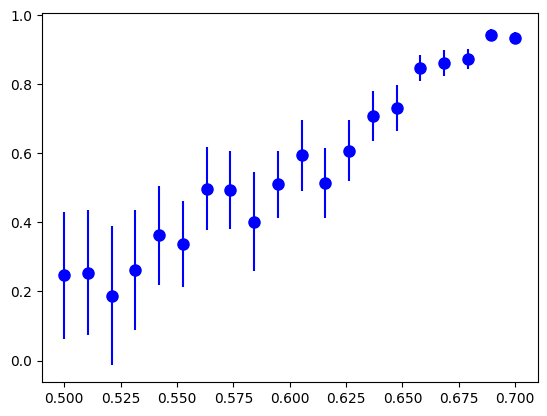

In [91]:
BC = []
for b in betas:
    BC.append(binder_jk(mags[b][::10,:], tc=0))
print(BC)
plot_gvcorr(BC, x=betas, xr_offset=False)

In [83]:
# Try to run at critical point
S8 = ACAction({'phi': phi8}, params={'beta': 0.6, 'lamb': 1})

HMC = lhmc.HMCEvolver(
    action=S8,
    seed=int(68015+b*138),
    integrator=lhmc.OmelyanIntegrator(eps=0.2, Nstep=5),
    observables={'mag': (mag_obs, 500)},
)

HMC.evolve(ntraj=500, warmup=True)

for _ in range(200):
    HMC.evolve(ntraj=1000)

In [84]:
binder_jk(np.array(HMC.obs_chain['mag']), tc=0)

0.562(31)

In [65]:
# Try to run at critical point
Lat16 = lat.SquareLattice(dims=(16,16))
phi16 = lat.LatticeField(Lat16)
phi16.field = np.ones_like(phi16.F)

S16 = ACAction({'phi': phi16}, params={'beta': 0.5985, 'lamb': 0.06268})

HMC = lhmc.HMCEvolver(
    action=S16,
    seed=int(68015+b*138),
    integrator=lhmc.OmelyanIntegrator(eps=0.2, Nstep=5),
    observables={'mag': (mag_obs, 5000)},
)

HMC.evolve(ntraj=500, warmup=True)

for _ in range(200):
    HMC.evolve(ntraj=1000)

In [69]:
np.mean(HMC.monitor['P_acc'])
binder_jk(np.array(HMC.obs_chain['mag'])[::1,:], tc=0)

0.9863(38)

In [70]:
# Volume scaling?
mags_V = {}

for L in [8, 12, 16, 24, 32]:
    LatV = lat.SquareLattice(dims=(L,L))
    phiV = lat.LatticeField(LatV)
    phiV.field = np.ones_like(phiV.F)

    SV = ACAction({'phi': phiV}, params={'beta': 0.5985, 'lamb': 0.06268})

    HMC = lhmc.HMCEvolver(
        action=SV,
        seed=int(81033+b*7311),
        integrator=lhmc.OmelyanIntegrator(eps=0.1, Nstep=10),
        observables={'mag': (mag_obs, 5000)},
    )

    HMC.evolve(ntraj=500, warmup=True)

    for _ in range(200):
        HMC.evolve(ntraj=1000)

    print(f"L = {L}: avg. accept prob = ", np.mean(HMC.monitor['P_acc']))

    mags_V[L] = np.array(HMC.obs_chain['mag'])


L = 8: avg. accept prob =  0.999997067634594
L = 12: avg. accept prob =  1.000000167326614
L = 16: avg. accept prob =  0.9999911313893742
L = 24: avg. accept prob =  0.9999972595654
L = 32: avg. accept prob =  0.9999882855577589


[0.940(18), 0.962(10), 0.9831(40), 0.9905(23), 0.9939(11)]
[ 8 12 16 24 32]


<ErrorbarContainer object of 3 artists>

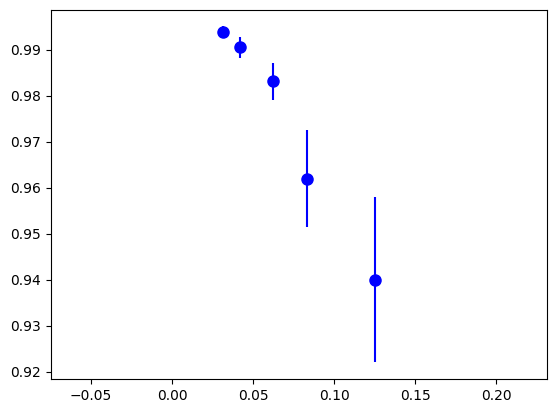

In [76]:
BC_V = []
for L in mags_V.keys():
    BC_V.append(binder_jk(mags_V[L], tc=0))
print(BC_V)
Ls = np.array(list(mags_V.keys()))
print(Ls)
plot_gvcorr(BC_V, x=1/Ls)